# Dynamical Similarity Analysis (DSA) Pipeline

This notebook compares the population dynamics of macaque motor cortex during
center-out reaching with the dynamics of two recurrent neural network (RNN)
models trained on the same task: a standard backpropagation-through-time
(BPTT) GRU and a Dale's-law-constrained GRU. Comparisons use Dynamical
Similarity Analysis (DSA; Ostrow et al., 2023, NeurIPS), implemented with the
`fastDSA` package, which measures similarity in a system's underlying
dynamics rather than its instantaneous representational geometry (RSA).

Biological data loading and preprocessing (event extraction, perievent
binning, per-session PCA, and Procrustes alignment) reuse the shared
`monkeypaw` package (`monkeypaw.io`, `monkeypaw.proc`). This notebook
implements the DSA-specific steps: building comparable trajectories from
both systems, computing pairwise DSA distances, and checking the stability
of those distances across random seeds.

Pipeline stages:

1. Setup
2. Load biological data
3. PCA reduction for artificial network activity
4. DSA core functions
5. Biological DSA datasets and within-dataset control test
6. Load RNN hidden-activity trajectories
7. Macaque vs. RNN pairwise DSA comparison
8. Three-system comparison (macaque vs. RNN-CB vs. RNN-Dale)
9. Representational-geometry trajectory path
10. Robustness check across random seeds

## 1. Setup

In [1]:
# Install the shared project package and DSA-specific dependencies (Google Colab).
!pip install -q git+https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git
!pip install -q motornet
!pip install -q pynapple dandi
!pip install -q git+https://github.com/CMC-lab/fastDSA.git
!pip install -q rsatoolbox

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 951.2 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.9/731.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.5/712.5 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.6/366.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━

In [6]:
# Mount Google Drive to access NWB files and RNN hidden-activity dumps.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns  # registers the "mako" colormap family

from scipy.spatial.distance import pdist
from sklearn import manifold

import torch
import torch.nn.functional as F
import pynapple as nap
import rsatoolbox
from fastDSA.simdist import SimDistConfig, FastDSASimilarity

from monkeypaw.io import nap_load_data, get_spike_count, get_behav, get_info
from monkeypaw.proc import compute_perievent, get_index_from_info, convert_peth_to_pcpeth

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Load biological data

Loads a single NWB session, extracts spike counts, behavioral variables, and
trial info with `monkeypaw.io`, then computes perievent spike-count tensors
aligned to the go cue with `monkeypaw.proc.compute_perievent`.

In [7]:
nwb_path = r"/content/drive/MyDrive/Dandi_Datasets/data/sub-Dataset-4-Animal-3-sess-7-to-11/sub-Dataset-4-Animal-3-sess-7-to-11.nwb"

data = nap_load_data(nwb_path)
spike_count = get_spike_count(data)
behav = get_behav(data)
info = get_info(data)
all_peth = compute_perievent(spike_count, behav, info, win=(-1, 2))

bio_peth = all_peth["peth_go"]
bio_info = all_peth["info_go"]
print("bio_peth shape (time, trial, cell):", bio_peth.shape)
bio_info.head()

Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_Onset', 'EventGo_cue', 'target_dir', 'target_ID', 'force_y', 'force_x', 'cursor_vel_y', 'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x', 'cursor_acc_y', 'cursor_acc_x']
bio_peth shape (time, trial, cell): (100, 1042, 96)


,trial_id,animal,datasetID,session,brain_region,target_ID,target_dir,result
0,3,3,4,7,M1,0.0,0.0,R
1,6,3,4,7,M1,1.0,0.0,R
2,7,3,4,7,M1,0.0,0.785398,R
3,9,3,4,7,M1,6.0,-2.356194,R
4,10,3,4,7,M1,3.0,3.141593,R


## 3. PCA reduction for artificial network activity

Biological perievent tensors are PCA-reduced and Procrustes-aligned across
sessions by `monkeypaw.proc.convert_peth_to_pcpeth`. `pca_reduce` provides
the equivalent step for RNN hidden-unit activity, which has no session
structure to align.

In [8]:
from sklearn.decomposition import PCA


def pca_reduce(data, npc=10):
    """Fit PCA jointly across all non-unit dimensions of `data`.

    Parameters
    ----------
    data : np.ndarray, shape (..., n_units)
        Any number of leading dimensions (e.g. trial x time). The last axis
        must be the unit/neuron axis.
    npc : int
        Number of principal components to keep.

    Returns
    -------
    pc_scores : np.ndarray, shape (..., npc)
    pca : fitted sklearn.decomposition.PCA
    """
    orig_shape = data.shape
    n_units = orig_shape[-1]
    if npc > n_units:
        raise ValueError(f"npc={npc} exceeds available units={n_units}")

    flat = np.asarray(data).reshape(-1, n_units)
    flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)

    pca = PCA(n_components=npc)
    scores = pca.fit_transform(flat)
    return scores.reshape(*orig_shape[:-1], npc), pca

## 4. DSA core functions

`plot_dsa_matrix` renders a pairwise distance matrix with the same visual
style used for RDM plots elsewhere in the project. `calc_DSA` wraps
`fastDSA` to compute an overall DSA distance between two sets of condition
trajectories and, optionally, the full pairwise distance matrix between all
of their conditions.

In [9]:
def angle_deg(val, n_conditions=8):
    """Normalize a condition value into one of the n_conditions compass angles.

    Accepts a raw direction index (0..n_conditions-1), an angle in radians,
    or an angle already in degrees, and rounds it onto the nearest grid angle
    (0, 45, 90, ... for n_conditions=8), so tick labels built from raw
    direction_idx / target_dir values are never noisy floating-point angles.
    """
    v = float(val)
    step = 360.0 / n_conditions
    if 0 <= v <= n_conditions - 1 and np.isclose(v, round(v)):
        deg = round(v) * step        # raw condition index (0..n_conditions-1)
    elif abs(v) <= 2 * np.pi + 1e-6:
        deg = np.degrees(v)          # radians
    else:
        deg = v                      # already degrees
    deg = round(deg / step) * step
    return int(deg % 360)


def plot_dsa_matrix(matrix, labels, cbar_label="DSA distance",
                     title="Pairwise DSA Distance", cmap="mako_r", figsize=None,
                     fmt="{:.4f}", group_boundaries=None):
    """Plot a square DSA distance matrix.

    Parameters
    ----------
    matrix : (N, N) array
    labels : list of str, length N. Tick labels for both axes.
    group_boundaries : list of int, optional. Row/column indices where a
        solid divider line should be drawn, e.g. the split between system
        A's and system B's rows in a concatenated pairwise matrix.
    figsize : (w, h), optional. Auto-scaled from N if not given.
    """
    matrix = np.asarray(matrix, dtype=float)
    n = matrix.shape[0]

    if figsize is None:
        side = max(5.0, min(0.32 * n + 3.5, 12.0))
        figsize = (side, side * 0.92)
    label_fs = 8 if n <= 18 else max(5.5, 8 - 0.12 * (n - 18))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap, interpolation="nearest")

    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor",
                        fontsize=label_fs, family="sans-serif")
    ax.set_yticklabels(labels, fontsize=label_fs, family="sans-serif")
    ax.set_title(title, fontsize=12, family="sans-serif", pad=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    if group_boundaries:
        line_fx = [pe.Stroke(linewidth=4, foreground="white"), pe.Normal()]
        for b in group_boundaries:
            ax.axhline(b - 0.5, color="black", lw=1.6, path_effects=line_fx)
            ax.axvline(b - 0.5, color="black", lw=1.6, path_effects=line_fx)

    vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
    vmid = (vmin + vmax) / 2

    fig.subplots_adjust(left=0.24, right=0.84, top=0.86, bottom=0.24)
    cbar_ax = fig.add_axes([0.88, 0.24, 0.03, 0.55])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=[vmin, vmid, vmax])
    cbar.ax.set_yticklabels([fmt.format(vmin), fmt.format(vmid), fmt.format(vmax)], fontsize=8)
    cbar.outline.set_linewidth(0.8)
    cbar.set_label(cbar_label, fontsize=10, rotation=90, labelpad=8)

    return fig, ax

In [10]:
def calc_DSA(data_a, data_b, cond_a=None, cond_b=None,
             n_delays=10, delay_interval=1, rank=10, method="ro", device="cpu",
             pairwise=True, pairwise_iters=200, pairwise_lr=1e-2, plot=True,
             label_a="A", label_b="B", n_conditions=8):
    """Compute the DSA distance between two sets of trajectories and, optionally, plot the pairwise matrix.

    Generalized so it can compare any two groups of trajectories: two
    networks (biological vs. artificial), two conditions, two sessions, two
    animals, and so on.

    Parameters
    ----------
    data_a, data_b : list of np.ndarray, each shaped (n_units/pc, n_timepoints)
        One array per trial/condition. fastDSA expects (channels, time).
        PCA-reduce first (Section 3) so `n_units` is matched between the two.
    cond_a, cond_b : array-like, optional
        Condition label per trial/condition. Can be a raw direction index
        (0..n_conditions-1), an angle in radians, or an angle in degrees;
        `angle_deg` normalizes any of these into a compass angle for the
        plot tick labels.
    n_delays, delay_interval, rank, method, device : fastDSA SimDistConfig settings.
    pairwise : bool
        Also compute the full pairwise (A+B) x (A+B) distance matrix and plot it.
    label_a, label_b : names used in the pairwise plot and print statements.
    n_conditions : int
        Number of distinct conditions/directions in the data (8 reach
        directions for this dataset), used to round angle labels onto the
        correct grid.

    Returns
    -------
    result : dict with keys
        'dsa_score'        - overall A vs. B DSA distance (lower = more similar)
        'pairwise_matrix'  - full pairwise distance matrix, if pairwise=True
        'origin'           - label_a/label_b per row/column of pairwise_matrix
        'cond_labels'      - condition label per row/column
    """
    cfg = SimDistConfig(
        n_delays=n_delays,
        delay_interval=delay_interval,
        rank=rank,
        method=method,
        device=device,
    )
    comparer = FastDSASimilarity(cfg)
    dsa_score, _ = comparer.fit_score(data_a, data_b)
    result = {"dsa_score": float(dsa_score)}

    if pairwise:
        n_a, n_b = len(data_a), len(data_b)
        all_trials = list(data_a) + list(data_b)
        N = len(all_trials)
        origin = np.array([label_a] * n_a + [label_b] * n_b)

        cond_lab = None
        if cond_a is not None and cond_b is not None:
            cond_lab = np.concatenate([np.asarray(cond_a), np.asarray(cond_b)])

        cfg_pw = SimDistConfig(n_delays=n_delays, delay_interval=delay_interval, rank=rank,
                                method=method, iters=pairwise_iters, lr=pairwise_lr, device=device)
        sim = FastDSASimilarity(cfg_pw)

        dist_mat = np.zeros((N, N))
        for i in range(N):
            for j in range(i + 1, N):
                d, _ = sim.fit_score([all_trials[i]], [all_trials[j]])
                dist_mat[i, j] = dist_mat[j, i] = float(d)

        result["pairwise_matrix"] = dist_mat
        result["origin"] = origin
        result["cond_labels"] = cond_lab

        if plot:
            if cond_lab is not None:
                # Sort by (angle, origin) so every direction appears exactly
                # once per system.
                angles = np.array([angle_deg(c, n_conditions) for c in cond_lab])
                sort_idx = np.lexsort((angles, origin))
                ticks = [f"{o}\n{a}\u00b0" for o, a in zip(origin[sort_idx], angles[sort_idx])]
            else:
                sort_idx = np.argsort(origin, kind="stable")
                ticks = [f"{o}_{i}" for i, o in enumerate(origin[sort_idx])]

            dist_sorted = dist_mat[np.ix_(sort_idx, sort_idx)]

            # Row/column index where the first group's block ends. lexsort's
            # primary key is `origin` (a string), so the group appearing
            # first in sorted order is not necessarily label_a; find the
            # boundary from the sorted origin array itself.
            origin_sorted = origin[sort_idx]
            change = np.where(origin_sorted[1:] != origin_sorted[:-1])[0]
            boundary = int(change[0]) + 1 if len(change) else N

            plot_dsa_matrix(
                dist_sorted, ticks,
                cbar_label="fastDSA distance",
                title=f"Pairwise DSA Distance ({label_a} vs {label_b}, method={method})\n"
                      f"Overall score: {dsa_score:.4f}",
                group_boundaries=[boundary],
            )

    return result

## 5. Biological DSA datasets and within-dataset control test

`make_dsa_datasets` mirrors `monkeypaw.analysis.make_rdm_datasets`: for each
animal it applies session-level PCA and alignment via
`convert_peth_to_pcpeth`, filters by brain region, and averages within reach
direction. Direction labels are first rounded onto the canonical eight-point
compass grid so that trial-to-trial calibration jitter in `target_dir` does
not split a single direction into duplicate conditions. Each direction's
trajectory is returned in fastDSA's (channels, timepoints) convention.

`run_dsa_test` then splits each animal's eight reach directions into two
halves and computes DSA between them, as a within-dataset control before any
biological-artificial comparison.

In [11]:
def make_dsa_datasets(peth: "nap.TsdTensor", ev_info: "pd.DataFrame", win=None):
    """Build DSA-ready trajectories from perievent data and event info.

    Parameters
    ----------
    peth : nap.TsdTensor
        Perievent time series data.
    ev_info : pd.DataFrame
        Event information corresponding to the perievent data.
    win : tuple(float, float), optional
        If given, restrict to a smaller window of time around the event
        before averaging (e.g. win=(0, 0.5) for the 500 ms after the event).

    Returns
    -------
    dsa_datasets : dict
        {animal: {'trials': [...], 'obs_descriptors': {...}, 'channel_descriptors': {...}}}
        'trials' is a list of (npc, n_time) arrays, one per target direction,
        ready to pass to `calc_DSA` (Section 4).
    """
    animal_idx = get_index_from_info(ev_info, "animal")
    dsa_datasets = {k: None for k in animal_idx.keys()}

    for animal, indices in animal_idx.items():
        animal_peth = peth[:, indices, :]
        animal_ev_info = ev_info.iloc[indices]

        # Keep animals recorded from a single brain region, excluding Area 2.
        brain_regions = np.unique(animal_ev_info["brain_region"])
        if len(brain_regions) > 1 or "Area2" in brain_regions:
            print(f"Animal {animal} has multiple brain regions or contains Area2. Skipping.")
            continue
        elif "PMd" in brain_regions:
            npc = 15
        elif "M1" in brain_regions:
            npc = 10
        else:
            print(f"Animal {animal} has an unrecognized brain region: {brain_regions}. Skipping.")
            continue

        # Session-level PCA and re-basing to a common coordinate frame.
        pcpeth = convert_peth_to_pcpeth(animal_peth, animal_ev_info, npc=npc)

        # convert_peth_to_pcpeth concatenates trials by session internally,
        # so rebuild ev_info in the same order to keep descriptors aligned.
        sess_idx = get_index_from_info(animal_ev_info, ["session"], out_pos=True)
        filtered_info = pd.concat(
            [animal_ev_info.iloc[idx] for idx in sess_idx.values()], axis=0
        ).reset_index(drop=True)
        filtered_peth = pcpeth

        if win is not None:
            filtered_peth = filtered_peth.restrict(nap.IntervalSet(start=win[0], end=win[1]))

        # Round target_dir onto the canonical compass grid before splitting
        # by direction, then average within each direction.
        raw_target_dir = filtered_info["target_dir"].values
        binned_target_dir = np.array([angle_deg(d, n_conditions=8) for d in raw_target_dir])

        target_dirs = np.unique(binned_target_dir)
        trials = []
        obs_target_dir, obs_target_id, obs_result = [], [], []
        for d in target_dirs:
            d_idx = np.where(binned_target_dir == d)[0]
            dir_peth = np.asarray(filtered_peth[:, d_idx, :].data())  # (n_time, n_trial_d, npc)
            dir_avg = np.nanmean(dir_peth, axis=1)                     # (n_time, npc)
            trials.append(dir_avg.T)                                   # (npc, n_time)

            obs_target_dir.append(d)
            obs_target_id.append(filtered_info["target_ID"].values[d_idx[0]])
            obs_result.append(pd.Series(filtered_info["result"].values[d_idx]).mode().iat[0])

        obs_descrip = {"target_dir": np.array(obs_target_dir),
                        "target_ID": np.array(obs_target_id),
                        "result": np.array(obs_result)}
        ch_descrip = {"animal": animal,
                      "session": np.unique(filtered_info["session"].values),
                      "brain_region": brain_regions[0]}

        dsa_datasets[animal] = {"trials": trials,
                                 "obs_descriptors": obs_descrip,
                                 "channel_descriptors": ch_descrip}

    return {k: v for k, v in dsa_datasets.items() if v is not None}

In [12]:
dsa_datasets = make_dsa_datasets(bio_peth, bio_info)
for animal, ds in dsa_datasets.items():
    n_dirs = len(ds["trials"])
    print(f"Animal {animal}: {n_dirs} target directions, "
          f"each trial shape {ds['trials'][0].shape} (npc, n_time)")

Animal 3: 8 target directions, each trial shape (10, 100) (npc, n_time)


Animal 3 (M1): DSA test score = 0.3366


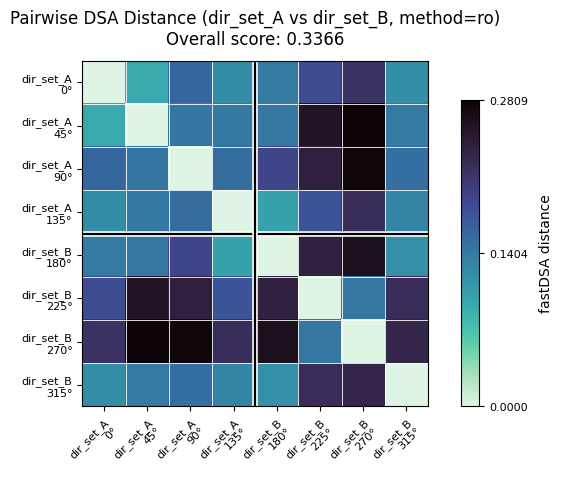

In [13]:
def run_dsa_test(dsa_datasets, **dsa_kwargs):
    """Run a within-dataset DSA control test on each animal's dataset.

    For each animal, the target directions from `make_dsa_datasets` are
    split into two halves and compared with `calc_DSA`, giving a baseline
    for "real, structured" dynamics before any biological-artificial
    comparison.

    Parameters
    ----------
    dsa_datasets : dict
        Output of `make_dsa_datasets`.
    **dsa_kwargs : passed through to `calc_DSA` (e.g. n_delays, rank, method).

    Returns
    -------
    results : dict of {animal: calc_DSA result dict}
    """
    results = {}
    for animal, ds in dsa_datasets.items():
        trials = ds["trials"]
        target_dirs = ds["obs_descriptors"]["target_dir"]

        half = len(trials) // 2
        group_a, group_b = trials[:half], trials[half:]
        dir_a, dir_b = target_dirs[:half], target_dirs[half:]

        region = ds["channel_descriptors"]["brain_region"]
        result = calc_DSA(group_a, group_b, cond_a=dir_a, cond_b=dir_b,
                           label_a="dir_set_A", label_b="dir_set_B", **dsa_kwargs)
        print(f"Animal {animal} ({region}): DSA test score = {result['dsa_score']:.4f}")
        results[animal] = result
    return results


dsa_test_results = run_dsa_test(dsa_datasets, plot=True)

In [14]:
report = pd.DataFrame([
    {"animal": a, "brain_region": dsa_datasets[a]["channel_descriptors"]["brain_region"],
     "n_target_dirs": len(dsa_datasets[a]["trials"]),
     "DSA_test_score": r["dsa_score"]}
    for a, r in dsa_test_results.items()
])
report

,animal,brain_region,n_target_dirs,DSA_test_score
0,3,M1,8,0.33659


### Interpreting the DSA score

`fastDSA` returns an unbounded distance: lower values indicate more similar
dynamics, and there is no fixed threshold for "similar enough". The score
above, computed between two halves of the same animal's reach directions,
gives a within-dataset baseline for structured dynamics. Biological vs.
artificial comparisons (Sections 7 to 9) should be read relative to this
baseline rather than in absolute terms.

## 6. Load RNN hidden-activity trajectories

Loads the two RNN hidden-activity dumps (`hidden_activity_CB.npz` for the
standard-backpropagation GRU and `hidden_activity_dale.npz` for the
Dale's-law-constrained GRU). Each file is expected to sit next to the
macaque NWB data (`drive_data_dir`), so nothing extra needs to be mounted if
Section 2 already ran.

In [15]:
try:
    rnn_data_dir = drive_data_dir
except NameError:
    rnn_data_dir = "/content/drive/MyDrive/Dandi_Datasets/data"

rnn_files = {
    "CB":   os.path.join(rnn_data_dir, "hidden_activity_CB.npz"),
    "dale": os.path.join(rnn_data_dir, "hidden_activity_dale.npz"),
}


def _load_hidden_activity_npz(path):
    """Load one RNN hidden-activity .npz file.

    Expected keys:
      'h_trace'        - hidden activity, shape (n_trial, n_time, n_units)
      'direction_idx'  - condition/target-direction label per trial, shape (n_trial,)
    (also present but unused for DSA: xy_trace, goal_trace, go_cue_time, is_catch, dt)
    """
    with np.load(path, allow_pickle=True) as f:
        keys = list(f.keys())
        activity_key = next((k for k in
                              ["h_trace", "hidden_activity", "activity", "hidden", "h", "rates"]
                              if k in keys), None)
        label_key = next((k for k in
                           ["direction_idx", "condition_labels", "conditions", "labels", "target_dir", "cond"]
                           if k in keys), None)

        if activity_key is None:
            activity_key = next((k for k in keys if np.asarray(f[k]).ndim == 3), None)
        if activity_key is None:
            raise KeyError(f"No hidden-activity array found in {path}. Available keys: {keys}")

        activity = np.asarray(f[activity_key])
        cond = np.asarray(f[label_key]) if label_key is not None else None
        print(f"Loaded '{activity_key}' from {os.path.basename(path)}: shape {activity.shape}, "
              f"labels '{label_key}' shape {None if cond is None else cond.shape}")
        return activity, cond


rnn_raw = {}
for name, path in rnn_files.items():
    activity, cond = _load_hidden_activity_npz(path)
    rnn_raw[name] = {"activity": activity, "condition_labels": cond}

for name, d in rnn_raw.items():
    n_cond = len(np.unique(d["condition_labels"])) if d["condition_labels"] is not None else 1
    print(f"{name}: activity {d['activity'].shape} (trial, time, unit), {n_cond} condition(s)")

Loaded 'h_trace' from hidden_activity_CB.npz: shape (8, 502, 32), labels 'direction_idx' shape (8,)
Loaded 'h_trace' from hidden_activity_dale.npz: shape (8, 502, 32), labels 'direction_idx' shape (8,)
CB: activity (8, 502, 32) (trial, time, unit), 8 condition(s)
dale: activity (8, 502, 32) (trial, time, unit), 8 condition(s)


## 7. Macaque vs. RNN pairwise DSA comparison

`make_dsa_dataset_from_activity` mirrors `make_dsa_datasets` (Section 5) for
a single RNN's raw hidden-activity array: PCA is fit jointly across trials
and time, then trajectories are averaged within condition. `run_dsa_mac_vs_rnn`
runs `calc_DSA` between every macaque animal's dynamics and every RNN's
dynamics, matching each comparison's PCA dimensionality to the macaque
animal's brain region (10 PCs for M1, 15 for PMd).

In [16]:
def make_dsa_dataset_from_activity(activity, condition_labels=None, npc=10, label="RNN"):
    """Build DSA-ready trajectories from a single RNN's raw hidden activity.

    Parameters
    ----------
    activity : np.ndarray, shape (n_trial, n_time, n_units)
    condition_labels : np.ndarray, shape (n_trial,), optional
        If None, all trials are treated as a single condition.
    npc : int
        Number of PCs to keep. Pass the macaque animal's npc so the two
        sides being compared have matched channel dimensionality.

    Returns
    -------
    dsa_dataset : dict with 'trials' (list of (npc, n_time) arrays, one per
        condition), 'obs_descriptors', 'channel_descriptors'; same shape as
        an entry of `dsa_datasets` from Section 5.
    """
    pc_scores, pca = pca_reduce(activity, npc=npc)  # (n_trial, n_time, npc)

    if condition_labels is None:
        condition_labels = np.zeros(activity.shape[0], dtype=int)
    conditions = np.unique(condition_labels)

    trials = []
    for c in conditions:
        c_idx = np.where(condition_labels == c)[0]
        c_avg = pc_scores[c_idx].mean(axis=0)   # (n_time, npc)
        trials.append(c_avg.T)                   # (npc, n_time)

    return {
        "trials": trials,
        "obs_descriptors": {"condition": conditions},
        "channel_descriptors": {"source": label, "n_units": activity.shape[-1], "npc": npc},
    }

Macaque 3 (M1) vs RNN 'CB': DSA score = 0.4759
Macaque 3 (M1) vs RNN 'dale': DSA score = 0.4563


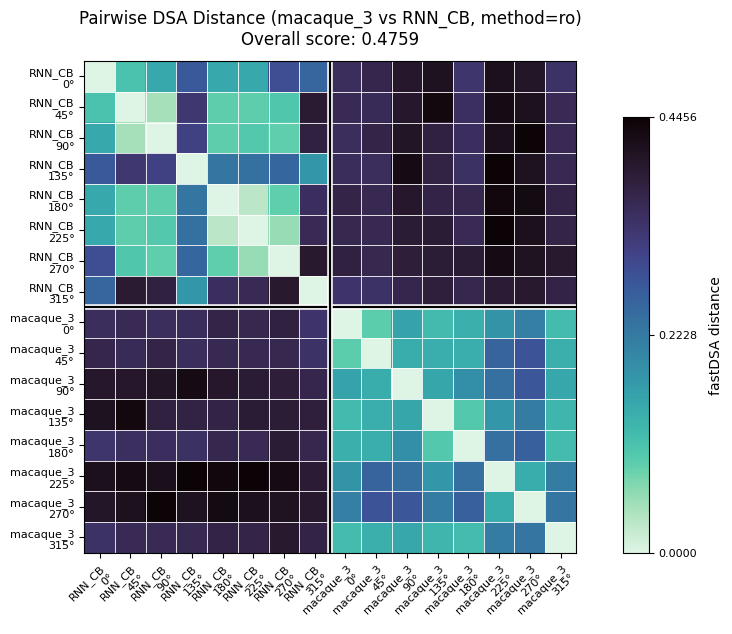

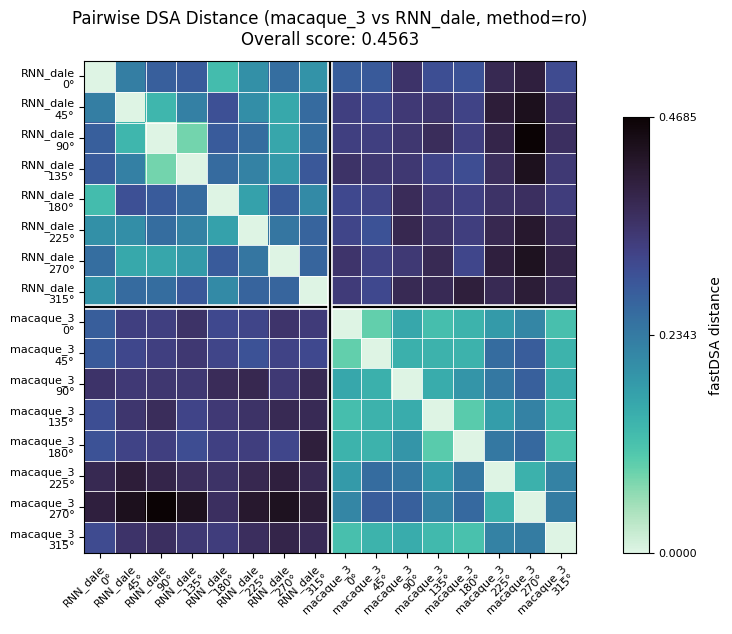

In [17]:
def run_dsa_mac_vs_rnn(dsa_datasets, rnn_raw, **dsa_kwargs):
    """Run calc_DSA between every macaque animal and every RNN.

    Parameters
    ----------
    dsa_datasets : dict
        Output of `make_dsa_datasets` (Section 5).
    rnn_raw : dict
        Output of Section 6, {name: {'activity': ..., 'condition_labels': ...}}.

    Returns
    -------
    results : dict of {(animal, rnn_name): calc_DSA result dict}
    rnn_dsa_cache : dict of {(animal, rnn_name): rnn dsa_dataset}, the PCA'd
        and condition-averaged RNN trajectories used for each comparison
        (npc varies by animal), reused for the trajectory overlay plot.
    """
    results, rnn_dsa_cache = {}, {}
    for animal, mac_ds in dsa_datasets.items():
        npc = mac_ds["trials"][0].shape[0]
        mac_trials = mac_ds["trials"]
        mac_cond = mac_ds["obs_descriptors"]["target_dir"]
        region = mac_ds["channel_descriptors"]["brain_region"]

        for rnn_name, d in rnn_raw.items():
            rnn_ds = make_dsa_dataset_from_activity(
                d["activity"], d["condition_labels"], npc=npc, label=rnn_name
            )
            rnn_trials = rnn_ds["trials"]
            rnn_cond = rnn_ds["obs_descriptors"]["condition"]

            result = calc_DSA(mac_trials, rnn_trials, cond_a=mac_cond, cond_b=rnn_cond,
                               label_a=f"macaque_{animal}", label_b=f"RNN_{rnn_name}",
                               **dsa_kwargs)
            print(f"Macaque {animal} ({region}) vs RNN '{rnn_name}': "
                  f"DSA score = {result['dsa_score']:.4f}")

            results[(animal, rnn_name)] = result
            rnn_dsa_cache[(animal, rnn_name)] = rnn_ds

    return results, rnn_dsa_cache


mac_vs_rnn_results, rnn_dsa_cache = run_dsa_mac_vs_rnn(dsa_datasets, rnn_raw, plot=True)

In [19]:
mac_vs_rnn_report = pd.DataFrame([
    {"animal": animal,
     "brain_region": dsa_datasets[animal]["channel_descriptors"]["brain_region"],
     "rnn_model": rnn_name,
     "DSA_score": r["dsa_score"]}
    for (animal, rnn_name), r in mac_vs_rnn_results.items()
]).sort_values(["animal", "rnn_model"]).reset_index(drop=True)

mac_vs_rnn_report

,animal,brain_region,rnn_model,DSA_score
0,3,M1,CB,0.475919
1,3,M1,dale,0.456346


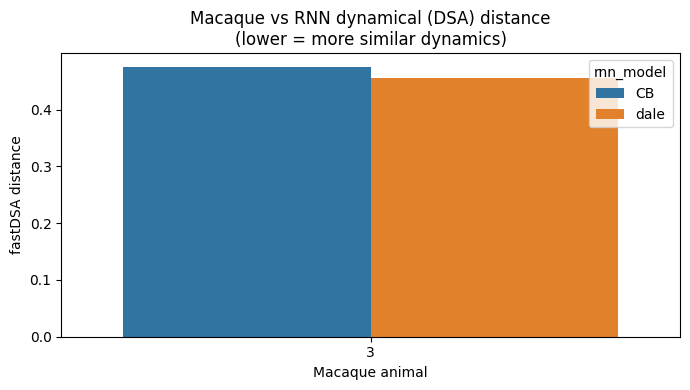

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=mac_vs_rnn_report, x="animal", y="DSA_score", hue="rnn_model", ax=ax)
ax.set_title("Macaque vs RNN dynamical (DSA) distance\n(lower = more similar dynamics)")
ax.set_ylabel("fastDSA distance")
ax.set_xlabel("Macaque animal")
plt.tight_layout()
plt.show()

## 8. Three-system comparison: macaque vs. RNN-CB vs. RNN-Dale

`make_dsa_datasets` and `make_dsa_dataset_from_activity` each build one
trajectory per unique condition seen in that system's own data. If the
macaque and the two RNNs do not share the exact same set of directions,
their trial lists end up different lengths, which breaks the RDM
concatenation used later in Section 9. `align_trials_by_condition` rounds
every system's condition labels onto the same compass-angle grid, keeps
only the angles common to all systems, and reorders every system's trials
to that common order.

In [21]:
def align_trials_by_condition(system_cond_trials, n_conditions=8):
    """Align multiple systems' trial lists onto the same set of conditions.

    Parameters
    ----------
    system_cond_trials : dict {system_name: (cond_labels, trials_list)}
        `cond_labels` is one condition value per entry of `trials_list` (raw
        direction index, radians, or degrees; anything `angle_deg` accepts).
        `trials_list` is a list of (npc, n_time) arrays, one per condition.
    n_conditions : int
        Size of the angle grid to round onto (8 for this dataset's reach
        directions).

    Returns
    -------
    aligned : dict {system_name: trials_list}, each reordered/subset to the
        common angles.
    common_angles : sorted list of the angles kept.
    """
    angle_lists = {
        name: [angle_deg(c, n_conditions) for c in conds]
        for name, (conds, _trials) in system_cond_trials.items()
    }

    common = set(next(iter(angle_lists.values())))
    for angs in angle_lists.values():
        common &= set(angs)
    common = sorted(common)

    if not common:
        raise ValueError(
            "No conditions/angles are shared across all systems. Check that "
            "condition labels (target_dir / direction_idx) correspond to "
            "the same set of reach directions."
        )
    if len(common) < n_conditions:
        dropped = sorted(set(range(0, 360, 360 // n_conditions)) - set(common))
        print(f"align_trials_by_condition: only {len(common)}/{n_conditions} "
              f"directions are common to every system (dropping {dropped} degrees).")

    aligned = {}
    for name, (conds, trials) in system_cond_trials.items():
        angs = angle_lists[name]
        angle_to_idx = {}
        for idx, a in enumerate(angs):
            angle_to_idx.setdefault(a, idx)
        aligned[name] = [trials[angle_to_idx[a]] for a in common]

    return aligned, common

Three-way comparison using 8 common directions: [0, 45, 90, 135, 180, 225, 270, 315]


(<Figure size 500x460 with 2 Axes>,
 <Axes: title={'center': 'Dynamical Similarity Analysis (DSA) score among trajectories\nMacaque 3 vs RNN-CB vs RNN-Dale'}>)

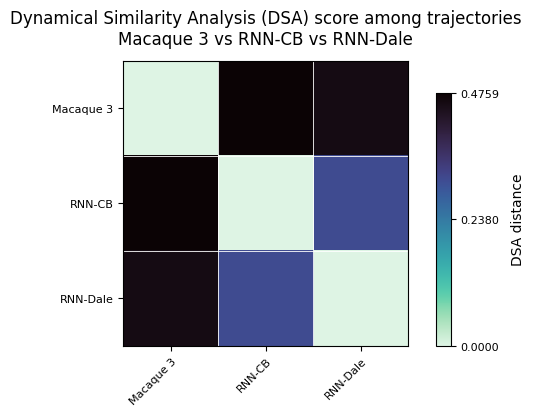

In [22]:
def compute_three_way_dsa(system_trials, **dsa_kwargs):
    """Compute a symmetric NxN matrix of overall calc_DSA scores (diagonal = 0).

    Parameters
    ----------
    system_trials : dict {system_name: list of (npc, n_time) trajectories}
    """
    names = list(system_trials.keys())
    n = len(names)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            r = calc_DSA(system_trials[names[i]], system_trials[names[j]],
                          pairwise=False, plot=False, **dsa_kwargs)
            mat[i, j] = mat[j, i] = r["dsa_score"]
    return mat, names


# Use one macaque animal as the reference and match both RNNs' PCA
# dimensionality to that animal's npc (10 for M1, 15 for PMd).
reference_animal = next(iter(dsa_datasets))
mac_trials = dsa_datasets[reference_animal]["trials"]
mac_cond = dsa_datasets[reference_animal]["obs_descriptors"]["target_dir"]
npc_ref = mac_trials[0].shape[0]

cb_ds = make_dsa_dataset_from_activity(
    rnn_raw["CB"]["activity"], rnn_raw["CB"]["condition_labels"], npc=npc_ref, label="RNN-CB")
dale_ds = make_dsa_dataset_from_activity(
    rnn_raw["dale"]["activity"], rnn_raw["dale"]["condition_labels"], npc=npc_ref, label="RNN-Dale")

aligned, common_angles = align_trials_by_condition({
    f"Macaque {reference_animal}": (mac_cond, mac_trials),
    "RNN-CB":   (cb_ds["obs_descriptors"]["condition"], cb_ds["trials"]),
    "RNN-Dale": (dale_ds["obs_descriptors"]["condition"], dale_ds["trials"]),
})
print(f"Three-way comparison using {len(common_angles)} common directions: {common_angles}")

mac_trials = aligned[f"Macaque {reference_animal}"]
cb_ds = dict(cb_ds, trials=aligned["RNN-CB"])
dale_ds = dict(dale_ds, trials=aligned["RNN-Dale"])

system_trials = {
    f"Macaque {reference_animal}": mac_trials,
    "RNN-CB": cb_ds["trials"],
    "RNN-Dale": dale_ds["trials"],
}

three_way_matrix, three_way_labels = compute_three_way_dsa(system_trials)

plot_dsa_matrix(
    three_way_matrix, three_way_labels,
    cbar_label="DSA distance",
    title=f"Dynamical Similarity Analysis (DSA) score among trajectories\n"
          f"Macaque {reference_animal} vs RNN-CB vs RNN-Dale",
)

## 9. Representational-geometry trajectory path

A complementary, RSA-based view of how the three systems' dynamics relate
to each other over time: an RDM is computed at each sampled timepoint from
the (n_conditions, npc) snapshot of all direction trajectories at that
instant, and the resulting RDM-of-RDMs is projected to two dimensions with
MDS. `build_time_sampled_features` skips the initial hold period before
sampling, since all conditions are close to identical while the hidden
state is near its (typically zero) initial value, which would otherwise
produce a degenerate RDM at the first few timepoints.

All three systems must have the same number of conditions going into this
step; `align_trials_by_condition` (Section 8) already enforces that.

In [27]:
def calc_rdms(features_dict, method="euclidean"):
    """Compute one RDM per entry of `features_dict`.

    Each entry corresponds to one sampled timepoint, holding the
    (n_conditions, npc) snapshot of all direction trajectories at that
    instant.
    """
    rdm_list, names = [], []
    for name, feat in features_dict.items():
        arr = feat.detach().cpu().numpy() if torch.is_tensor(feat) else np.asarray(feat)
        arr = arr.reshape(arr.shape[0], -1)
        ds = rsatoolbox.data.Dataset(arr)
        rdm_list.append(rsatoolbox.rdm.calc.calc_rdm(ds, method=method))
        names.append(name)
    rdms = rsatoolbox.rdm.concat(rdm_list)
    return rdms, names


def first_informative_timepoint(trials, tol=1e-6):
    """Return the first timepoint at which the condition-wise RDM is non-degenerate.

    Before the trajectories diverge from each other (e.g. during a zero-init
    hold period), every condition looks identical, giving a zero-vector RDM
    that breaks cosine comparisons downstream.

    Parameters
    ----------
    trials : list of (npc, n_time) arrays, one per condition (direction).
    """
    n_time = trials[0].shape[1]
    for ti in range(n_time):
        snap = np.stack([tr[:, ti] for tr in trials], axis=0)  # (n_conditions, npc)
        if np.linalg.norm(pdist(snap)) > tol:
            return ti
    return 0


def build_time_sampled_features(trials, n_samples=12, skip_first="auto"):
    """Subsample a (n_conditions, npc) snapshot at evenly spaced timepoints.

    Parameters
    ----------
    trials : list of (npc, n_time) arrays, one per condition (direction).
    n_samples : int
        Number of timepoints to sample.
    skip_first : "auto" or int
        Number of initial timepoints to skip before sampling. "auto" detects
        this per system with `first_informative_timepoint`.
    """
    n_time = trials[0].shape[1]
    start = first_informative_timepoint(trials) if skip_first == "auto" else skip_first
    start = min(start, n_time - 1)
    sample_idx = np.linspace(start, n_time - 1, min(n_samples, n_time - start)).astype(int)
    return {f"t{ti}": np.stack([tr[:, ti] for tr in trials], axis=0) for ti in sample_idx}

In [23]:
def rep_path(model_features, model_colors, labels=None, rdm_calc_method="euclidean", rdm_comp_method="cosine"):
    """Plot the representational-geometry path of each system over time.

    Parameters
    ----------
    model_features : dict {model_name: {timepoint_label: (n_conditions, npc) array}}
        Output of `build_time_sampled_features` for each system. Every
        system must have the same number of conditions (see
        `align_trials_by_condition`, Section 8).
    model_colors : dict {model_name: color}
    labels : array-like, optional
        Class labels to plot as an additional reference point.
    rdm_calc_method : "euclidean" or "correlation"
    rdm_comp_method : "cosine" or "corr"
    """
    path_len = []
    path_colors = []
    rdms_list = []
    ax_ticks = []
    tick_colors = []
    model_names = list(model_features.keys())
    for model_name in model_names:
        features = model_features[model_name]
        path_colors.append(model_colors[model_name])
        path_len.append(len(features))
        ax_ticks.append(list(features.keys()))
        tick_colors.append([model_colors[model_name]] * len(features))
        rdms, _ = calc_rdms(features, method=rdm_calc_method)
        rdms_list.append(rdms)

    path_len = np.insert(np.cumsum(path_len), 0, 0)

    if labels is not None:
        rdms, _ = calc_rdms({"labels": F.one_hot(labels).float().to(device)}, method=rdm_calc_method)
        rdms_list.append(rdms)
        ax_ticks.append(["labels"])
        tick_colors.append(["m"])
        idx_labels = -1

    rdms = rsatoolbox.rdm.concat(rdms_list)

    ax_ticks = [l for model_layers in ax_ticks for l in model_layers]
    tick_colors = [l for model_layers in tick_colors for l in model_layers]
    tick_colors = ["k" if tick == "input" else color for tick, color in zip(ax_ticks, tick_colors)]

    rdms_comp = rsatoolbox.rdm.compare(rdms, rdms, method=rdm_comp_method)
    if rdm_comp_method == "cosine":
        rdms_comp = np.arccos(rdms_comp)
    rdms_comp = np.nan_to_num(rdms_comp, nan=0.0)
    rdms_comp = (rdms_comp + rdms_comp.T) / 2.0  # symmetrize

    transformer = manifold.MDS(n_components=2, max_iter=1000, n_init=10,
                                normalized_stress="auto", dissimilarity="precomputed")
    dims = transformer.fit_transform(rdms_comp)

    # Remove duplicate "input" ticks from multiple models, if present.
    remove_duplicates = np.where(np.array(ax_ticks) == "input")[0][1:]
    for index in remove_duplicates:
        del ax_ticks[index]
        del tick_colors[index]
        rdms_comp = np.delete(np.delete(rdms_comp, index, axis=0), index, axis=1)

    fig = plt.figure(figsize=(9, 4.5))
    gs = fig.add_gridspec(1, 2)
    fig.subplots_adjust(wspace=0.35, hspace=0.2)

    # Left panel: timepoint-RDM dissimilarity matrix.
    ax = plt.subplot(gs[0, 0])
    n_ticks = len(ax_ticks)
    im = ax.imshow(rdms_comp, cmap="mako_r", interpolation="nearest")
    ax.set_xticks(np.arange(-0.5, n_ticks, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_ticks, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    fig.subplots_adjust(left=0.2)
    cbar_ax = fig.add_axes([-0.03, 0.2, 0.015, 0.5])
    cbar = fig.colorbar(im, cax=cbar_ax, location="left")
    cbar.outline.set_linewidth(0.8)
    ax.set_title("Dissimilarity between timepoint RDMs\n(Macaque vs RNN-CB vs RNN-Dale)",
                 fontdict={"fontsize": 12, "family": "sans-serif"})
    ax.set_xticks(np.arange(n_ticks), labels=ax_ticks, fontsize=7, rotation=83, family="sans-serif")
    ax.set_yticks(np.arange(n_ticks), labels=ax_ticks, fontsize=7, family="sans-serif")
    for color, tick in zip(tick_colors, ax.xaxis.get_ticklabels()):
        tick.set_color(color)
    for color, tick in zip(tick_colors, ax.yaxis.get_ticklabels()):
        tick.set_color(color)

    # Right panel: representational-geometry path over time (MDS).
    ax = plt.subplot(gs[0, 1])
    amin, amax = dims.min(), dims.max()
    amin, amax = (amin + amax) / 2 - (amax - amin) * 5 / 8, (amin + amax) / 2 + (amax - amin) * 5 / 8

    n_paths = len(rdms_list) - 1 if labels is not None else len(rdms_list)
    for i in range(n_paths):
        path_indices = np.arange(path_len[i], path_len[i + 1])
        ax.plot(dims[path_indices, 0], dims[path_indices, 1], color=path_colors[i], marker=".")
    ax.set_title("Representational geometry path over time",
                 fontdict={"fontsize": 12, "family": "sans-serif"})
    ax.set_xlim([amin, amax])
    ax.set_ylim([amin, amax])
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

    ax.plot(dims[0, 0], dims[0, 1], color="k", marker="s")
    if labels is not None:
        ax.plot(dims[idx_labels, 0], dims[idx_labels, 1], color="m", marker="*")

    ax.legend(model_names, fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig

/tmp/ipykernel_18106/2734309681.py:48: RuntimeWarning: invalid value encountered in arccos
  rdms_comp = np.arccos(rdms_comp)
/tmp/ipykernel_18106/2734309681.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


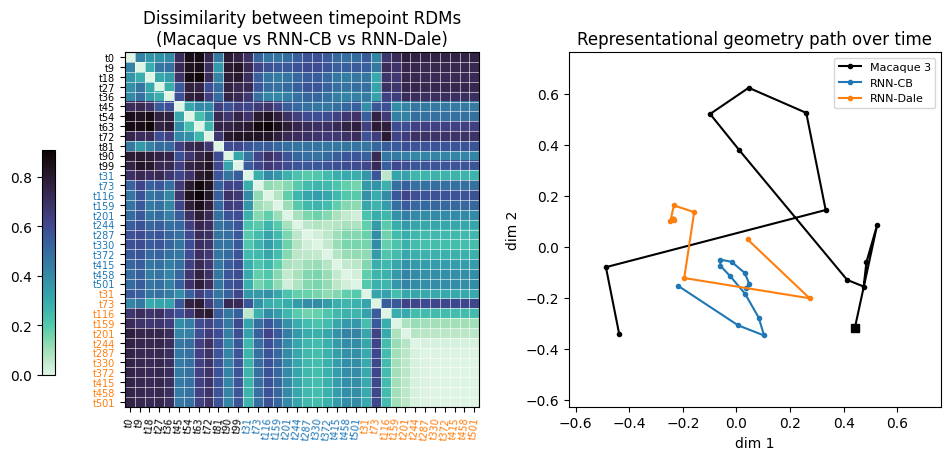

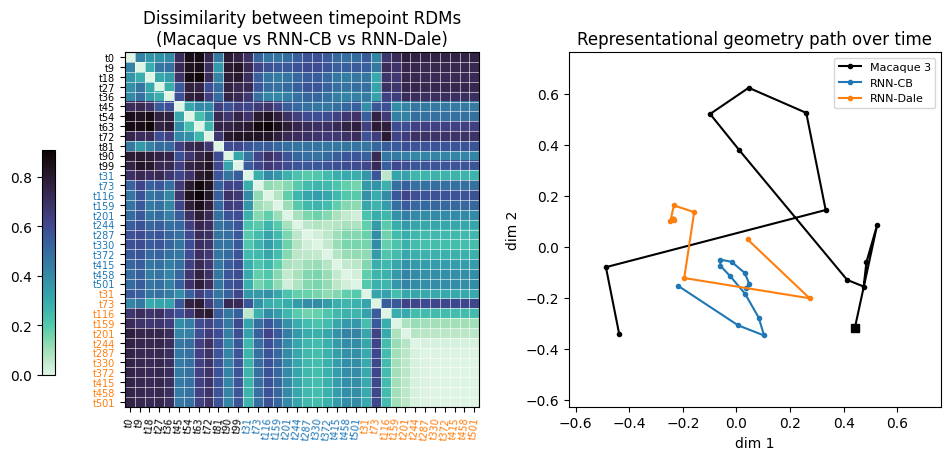

In [28]:
model_features = {
    f"Macaque {reference_animal}": build_time_sampled_features(mac_trials),
    "RNN-CB":   build_time_sampled_features(cb_ds["trials"]),
    "RNN-Dale": build_time_sampled_features(dale_ds["trials"]),
}
model_colors = {
    f"Macaque {reference_animal}": "black",
    "RNN-CB":   "tab:blue",
    "RNN-Dale": "tab:orange",
}

rep_path(model_features, model_colors, labels=None,
         rdm_calc_method="euclidean", rdm_comp_method="cosine")

## 10. Robustness check across random seeds

`fastDSA`'s Procrustes alignment step is a stochastic optimization, so a
single `dsa_score` is a point estimate rather than a guaranteed-stable
number. Each macaque-vs-RNN comparison is rerun across ten seeds, and the
mean and standard deviation are reported; if two comparisons' standard
deviations overlap, the difference between them should be treated as noise
rather than as a reliable effect.

In [24]:
def calc_DSA_repeated(data_a, data_b, cond_a=None, cond_b=None, n_repeats=10,
                       seeds=None, label_a="A", label_b="B", **dsa_kwargs):
    """Rerun calc_DSA n_repeats times with different RNG seeds and report the spread.

    Returns
    -------
    dict with 'scores' (array, len n_repeats), 'mean', 'std', 'seeds'.
    """
    if seeds is None:
        seeds = list(range(n_repeats))
    scores = []
    for s in seeds:
        np.random.seed(s)
        torch.manual_seed(s)
        r = calc_DSA(data_a, data_b, cond_a=cond_a, cond_b=cond_b,
                      label_a=label_a, label_b=label_b, plot=False, pairwise=False,
                      **dsa_kwargs)
        scores.append(r["dsa_score"])
    scores = np.array(scores)
    return {"scores": scores, "mean": scores.mean(), "std": scores.std(), "seeds": seeds}


N_REPEATS = 10
robustness_results = {}
for animal, mac_ds in dsa_datasets.items():
    npc = mac_ds["trials"][0].shape[0]
    m_trials = mac_ds["trials"]
    m_cond = mac_ds["obs_descriptors"]["target_dir"]
    for rnn_name, d in rnn_raw.items():
        rnn_ds = make_dsa_dataset_from_activity(
            d["activity"], d["condition_labels"], npc=npc, label=rnn_name)
        res = calc_DSA_repeated(
            m_trials, rnn_ds["trials"], cond_a=m_cond,
            cond_b=rnn_ds["obs_descriptors"]["condition"],
            n_repeats=N_REPEATS, label_a=f"macaque_{animal}", label_b=f"RNN_{rnn_name}")
        robustness_results[(animal, rnn_name)] = res
        print(f"{animal} vs {rnn_name}: mean={res['mean']:.4f} +/- {res['std']:.4f} (n={N_REPEATS})")

robustness_df = pd.DataFrame([
    {"animal": a, "rnn_model": r, "mean_DSA": res["mean"], "std_DSA": res["std"]}
    for (a, r), res in robustness_results.items()
]).sort_values(["animal", "rnn_model"]).reset_index(drop=True)
robustness_df

3 vs CB: mean=0.4759 +/- 0.0000 (n=10)
3 vs dale: mean=0.4563 +/- 0.0000 (n=10)


,animal,rnn_model,mean_DSA,std_DSA
0,3,CB,0.475919,0.0
1,3,dale,0.456346,0.0


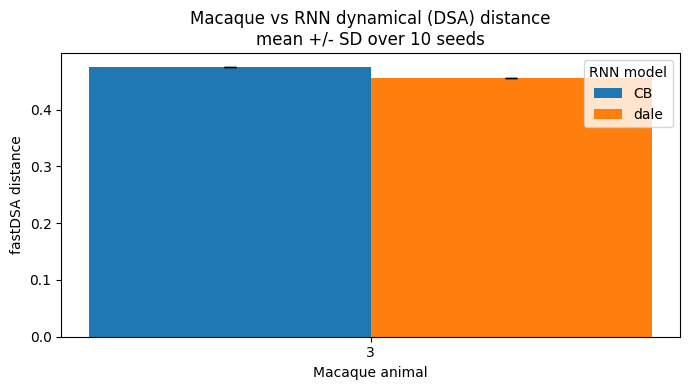

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
animals = sorted(robustness_df["animal"].unique())
models = sorted(robustness_df["rnn_model"].unique())
x = np.arange(len(animals))
width = 0.8 / len(models)
colors = plt.cm.tab10.colors
for i, m in enumerate(models):
    sub = robustness_df[robustness_df.rnn_model == m].set_index("animal").reindex(animals)
    ax.bar(x + (i - (len(models) - 1) / 2) * width, sub["mean_DSA"], width,
           yerr=sub["std_DSA"], capsize=4, label=m, color=colors[i % len(colors)])
ax.set_xticks(x)
ax.set_xticklabels(animals)
ax.set_title(f"Macaque vs RNN dynamical (DSA) distance\nmean +/- SD over {N_REPEATS} seeds")
ax.set_ylabel("fastDSA distance")
ax.set_xlabel("Macaque animal")
ax.legend(title="RNN model")
plt.tight_layout()
plt.show()

## Summary

This pipeline produces, for each macaque animal with a usable brain-region
label: a within-dataset DSA control score (Section 5), a pairwise DSA
distance to each of the two RNN models with seed-averaged mean and standard
deviation (Sections 7 and 10), a three-system DSA distance matrix (Section
8), and a representational-geometry trajectory path across all three
systems (Section 9).

Two caveats apply when interpreting these results. First, each animal
contributes at most eight direction-averaged trajectories, so per-animal
DSA estimates are based on a small number of conditions; the robustness
check in Section 10 should be read alongside any reported score. Second,
`fastDSA` distances are unbounded and have no fixed similarity threshold,
so RNN-macaque scores should be interpreted relative to the within-dataset
control score for the same animal, not as an absolute measure of
biological plausibility.